# N16 — Undercut Success Predictor

An undercut is one of the most decisive tactical moves in F1: pitting before a rival to gain track position through fresher tyre pace. But it only works if the time lost in the pit lane (pit delta) is smaller than the gap you need to bridge. This notebook builds a binary classifier that predicts whether a given undercut attempt will succeed — defined as driver X gaining net position over rival Y after both complete their pit sequences.

## What is an undercut?

Driver X is behind driver Y by gap G. X pits first. Y stays out for ≤ 5 laps, then also pits.
After both are on new tyres and the pit sequence is complete, if X is ahead of Y: **undercut successful**.

The outcome depends on three competing forces:
- **Pit delta**: time lost by X entering the pit lane (inlap + outlap vs. two normal laps). If pit_delta > G, X exits behind Y even with fresher tyres.
- **Fresh tyre pace gain**: X's new tyres are faster than Y's worn ones. Each lap Y stays out, X closes the gap.
- **Track position value**: at circuits where overtaking is hard, even a small position gain is decisive.

## Modeling approach

Binary LightGBM classifier (same architecture as N12/N14). Target: `undercut_success = 1` if X
gains position over Y after the pit sequence. Labels constructed from FastF1 race data (2023–2025)
by detecting pit sequences where one driver pits within 5 laps of the other.

The `pit_delta` feature is derived analytically:


---

## Step 0: Setup and Data Labeling

### Imports and dir setup

In [1]:
# ── Step 0 · Setup ────────────────────────────────────────────────────────────
import sys
import json
import joblib
import unicodedata
import logging
import warnings
from pathlib import Path

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import fastf1
import lightgbm as lgb
import optuna
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_recall_curve,
    classification_report,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

repo_root = Path.cwd()
while not (repo_root / ".git").exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

CACHE_DIR  = repo_root / "data" / "cache" / "fastf1"
EXPORT_DIR = repo_root / "data" / "models" / "pit_prediction"
PROC_DIR   = repo_root / "data" / "processed" / "undercut_labeled"
OUTPUTS    = repo_root / "notebooks" / "strategy" / "pit_prediction" / "outputs"

for d in [CACHE_DIR, EXPORT_DIR, PROC_DIR, OUTPUTS]:
    d.mkdir(parents=True, exist_ok=True)

logging.getLogger("fastf1").setLevel(logging.WARNING)
fastf1.Cache.enable_cache(str(CACHE_DIR))

### Data Labeling and computing

In [2]:
YEARS = [2023, 2024, 2025]
# Maximum laps between X pitting and Y pitting for it to count as an undercut attempt
MAX_LAP_GAP = 5

In [3]:
def compute_pit_delta(laps_driver, pit_lap):
    """
    pit_delta = inlap_time + outlap_time - 2 × median_race_lap
    inlap  = lap where PitInTime is set (lap N)
    outlap = lap where PitOutTime is set (lap N+1)
    median_race_lap = median of all 'normal' laps (IsAccurate=True, no pit in/out)
    """
    normal = laps_driver[
        laps_driver["IsAccurate"] &
        laps_driver["PitInTime"].isna() &
        laps_driver["PitOutTime"].isna()
    ]["LapTime"].dt.total_seconds().dropna()

    if len(normal) < 3:
        return np.nan

    median_lap = normal.median()

    inlap_row  = laps_driver[laps_driver["LapNumber"] == pit_lap]
    outlap_row = laps_driver[laps_driver["LapNumber"] == pit_lap + 1]

    if inlap_row.empty or outlap_row.empty:
        return np.nan

    inlap_t  = inlap_row["LapTime"].dt.total_seconds().values[0]
    outlap_t = outlap_row["LapTime"].dt.total_seconds().values[0]

    if pd.isna(inlap_t) or pd.isna(outlap_t):
        return np.nan

    return inlap_t + outlap_t - 2 * median_lap

In [4]:
def _build_ts_lookup(laps):
    """Build a {lap_number: track_status} dict from session laps (race-wide signal)."""
    return laps.groupby("LapNumber")["TrackStatus"].first().to_dict()


def _has_sc_in_range(ts_lookup, lap_x, lap_y):
    """Return True if any lap in [lap_x, lap_y] has SC or VSC status."""
    sc_codes = {"4", "5", "6", "7"}
    return any(
        sc_codes & set(str(ts_lookup.get(lap, "1")))
        for lap in range(int(lap_x), int(lap_y) + 1)
    )


def _label_gp_pairs(laps, year, gp, circuit_key, total_laps, max_lap_gap, ts_lookup):
    """Return a list of undercut pair records for a single GP session."""
    pit_laps = laps[laps["PitInTime"].notna()][[
        "Driver", "Team", "LapNumber", "Compound", "TyreLife", "PitInTime", "Position"
    ]].copy()

    records = []
    for drv_x in pit_laps["Driver"].unique():
        pits_x = pit_laps[pit_laps["Driver"] == drv_x]
        laps_x = laps[laps["Driver"] == drv_x]

        for _, pit_x in pits_x.iterrows():
            lap_x        = int(pit_x["LapNumber"])
            pos_x_before = pit_x["Position"]
            if pd.isna(pos_x_before):
                continue

            rivals = pit_laps[
                (pit_laps["Driver"] != drv_x) &
                (pit_laps["LapNumber"] > lap_x) &
                (pit_laps["LapNumber"] <= lap_x + max_lap_gap)
            ]

            for _, pit_y in rivals.iterrows():
                drv_y  = pit_y["Driver"]
                lap_y  = int(pit_y["LapNumber"])
                laps_y = laps[laps["Driver"] == drv_y]

                y_at_lap_x = laps_y[laps_y["LapNumber"] == lap_x]
                if y_at_lap_x.empty:
                    continue
                pos_y_at_pit_x = y_at_lap_x["Position"].values[0]
                if pd.isna(pos_y_at_pit_x) or pos_x_before <= pos_y_at_pit_x:
                    continue

                check_lap = lap_y + 3
                x_after   = laps_x[laps_x["LapNumber"] == check_lap]
                y_after   = laps_y[laps_y["LapNumber"] == check_lap]
                if x_after.empty or y_after.empty:
                    continue

                pos_x_after = x_after["Position"].values[0]
                pos_y_after = y_after["Position"].values[0]
                if pd.isna(pos_x_after) or pd.isna(pos_y_after):
                    continue

                records.append({
                    "Year":             year,
                    "GP_Name":          gp,
                    "circuit_key":      circuit_key,
                    "Driver_X":         drv_x,
                    "Team_X":           pit_x["Team"],
                    "Driver_Y":         drv_y,
                    "Team_Y":           pit_y["Team"],
                    "Lap_X_pits":       lap_x,
                    "Lap_Y_pits":       lap_y,
                    "Lap_gap":          lap_y - lap_x,
                    "total_laps":       total_laps,
                    "TyreLife_X":       pit_x["TyreLife"],
                    "TyreLife_Y":       pit_y["TyreLife"],
                    "Compound_X":       pit_x["Compound"],
                    "Compound_Y":       pit_y["Compound"],
                    "pos_X_before":     pos_x_before,
                    "pos_Y_before":     pos_y_at_pit_x,
                    "pit_delta_X":      compute_pit_delta(laps_x, lap_x),
                    "has_sc":           _has_sc_in_range(ts_lookup, lap_x, lap_y),
                    "undercut_success": int(pos_x_after < pos_y_after),
                })
    return records


def label_undercuts(years, max_lap_gap=MAX_LAP_GAP):
    """Load all race sessions and label undercut attempt pairs across seasons."""
    all_records = []

    for year in years:
        schedule = fastf1.get_event_schedule(year, include_testing=False)
        gp_names = schedule[schedule["EventFormat"] != "testing"]["EventName"].tolist()

        for gp in gp_names:
            try:
                session = fastf1.get_session(year, gp, "R")
                session.load(laps=True, telemetry=False, weather=False, messages=False)
            except Exception as e:
                print(f"  SKIP {year} {gp}: {e}")
                continue

            laps        = session.laps.copy()
            circuit_key = session.event["Location"]
            total_laps  = int(laps["LapNumber"].max())
            ts_lookup   = _build_ts_lookup(laps)
            gp_records  = _label_gp_pairs(laps, year, gp, circuit_key, total_laps, max_lap_gap, ts_lookup)
            all_records.extend(gp_records)
            print(f"  {year} {gp}: {len(gp_records)} pairs")

    df = pd.DataFrame(all_records)
    print(f"\nTotal undercut pairs labeled: {len(df)}")
    print(f"Success rate: {df['undercut_success'].mean():.1%}")
    return df

#### One more step needed: undercut filtering by position proximity

Some labeled pairs are not real undercut attempts — e.g. Gasly (P19) pitting 2 laps
before Verstappen (P1) is pure coincidence, not a tactical decision.

A real undercut targets cars **within striking distance on track**. In F1 this means:
- **1 position gap**: the classic direct undercut (X attacks the car immediately ahead)
- **2 position gap**: X targets the leader of a small group, jumping two cars at once
- **3 position gap**: the maximum realistic scope — when 3–4 cars are running closely
  together, a team may plan to undercut the whole group in one move

Beyond 3 positions, the cars are too spread out for the undercut to be a deliberate
tactical choice. We therefore keep only pairs where
`|pos_X_before − pos_Y_before| ≤ 3`.


In [5]:
def filter_real_undercuts(df, max_pos_gap=3):
    """
    Keep only pairs where X and Y are within max_pos_gap positions of each other
    when X enters the pit lane. Beyond 3 positions the cars are too spread out
    for the undercut to be a deliberate tactical decision.
    """
    before = len(df)
    df = df[(df["pos_X_before"] - df["pos_Y_before"]).abs() <= max_pos_gap].copy()
    after = len(df)
    print(f"Position filter (≤{max_pos_gap} pos apart): {before} → {after} "
          f"({before - after} removed, {(before-after)/before*100:.1f}%)")
    print(f"Success rate: {df['undercut_success'].mean():.1%}")
    print(df["undercut_success"].value_counts())
    return df





In [6]:
df_raw = label_undercuts(YEARS)
print(df_raw["undercut_success"].value_counts())
print(df_raw.head())

df = filter_real_undercuts(df_raw)

  2023 Bahrain Grand Prix: 216 pairs


core        WARNING 	Driver 11 completed the race distance 00:00.035000 before the recorded end of the session.


  2023 Saudi Arabian Grand Prix: 62 pairs
  2023 Australian Grand Prix: 91 pairs
  2023 Azerbaijan Grand Prix: 89 pairs
  2023 Miami Grand Prix: 35 pairs
  2023 Monaco Grand Prix: 156 pairs


core        WARNING 	Driver 1 completed the race distance 00:00.037000 before the recorded end of the session.


  2023 Spanish Grand Prix: 98 pairs


...

  2025 Singapore Grand Prix: 41 pairs
  2025 United States Grand Prix: 66 pairs
  2025 Mexico City Grand Prix: 45 pairs


core        WARNING 	Driver 4 completed the race distance 00:00.010000 before the recorded end of the session.
core        WARNING 	Fixed incorrect tyre stint information for driver '63'


  2025 São Paulo Grand Prix: 68 pairs


events      WARNING 	Correcting user input 'Qatar Grand Prix' to 'Qatar Grand Prix'


  2025 Las Vegas Grand Prix: 44 pairs
  2025 Qatar Grand Prix: 23 pairs
  2025 Abu Dhabi Grand Prix: 48 pairs

Total undercut pairs labeled: 7149
Success rate: 15.0%
undercut_success
0    6075
1    1074
Name: count, dtype: int64
   Year             GP_Name circuit_key Driver_X  Team_X Driver_Y  \
0  2023  Bahrain Grand Prix      Sakhir      GAS  Alpine      VER   
1  2023  Bahrain Grand Prix      Sakhir      GAS  Alpine      ALO   
2  2023  Bahrain Grand Prix      Sakhir      GAS  Alpine      LEC   
3  2023  Bahrain Grand Prix      Sakhir      GAS  Alpine      SAR   
4  2023  Bahrain Grand Prix      Sakhir      GAS  Alpine      DEV   

            Team_Y  Lap_X_pits  Lap_Y_pits  Lap_gap  total_laps  TyreLife_X  \
0  Red Bull Racing           9          14        5          57         9.0   
1     Aston Martin           9          14        5          57         9.0   
2          Ferrari           9          13        4          57         9.0   
3         Williams           9          

### Step 0 Results

The labeling pipeline processed **3 full seasons (2023–2025)** across all available GPs, identifying undercut attempt pairs where:
- Driver X pitted **up to 5 laps before** Driver Y
- Both drivers were **within 3 positions** of each other before X's pit stop

**Dataset summary:**
| Metric | Value |
|---|---|
| Total undercut pairs | 7,149 |
| Successful undercuts | 1,074 (15.0%) |
| Failed undercuts | 6,075 (85.0%) |

The 15% success rate reflects the real difficulty of the undercut: pitting early only converts to a position gain roughly 1 in 7 times, even when the position proximity filter ensures these are genuine tactical attempts and not random pit pairs.

The class imbalance (≈1:5.6) is moderate — less extreme than the SC model (1:28) but still meaningful for model training. `scale_pos_weight` will be tuned accordingly in Step 3.

---

## Step 1: Exploratory Data Analysis

Before any modelling, we need to understand what the labeled dataset actually looks like and which raw signals correlate with undercut success.

This step covers:
- **Dataset overview**: shape, dtypes, missing values, target distribution
- **Success rate by year and circuit**: are some venues/seasons more undercut-friendly?
- **Compound transition effect**: does the tyre type being fitted (fresh soft vs medium) matter?
- **Timing of the undercut**: does pitting 1 lap vs 5 laps earlier change the odds?
- **Position gap and tyre age distributions**: do successful undercuts share a structural profile?

The goal is to surface the 3–4 strongest raw predictors before feature engineering in Step 2, and flag any data quality issues early.


In [7]:
# ── Step 1 · EDA ─────────────────────────────────────────────────────────────
def dataset_overview(df):
    print("=== Dataset Overview ===")
    print(f"Shape: {df.shape}")
    print(f"\nColumns:\n{df.dtypes}")
    print(f"\nMissing values:\n{df.isnull().sum()}")
    print(f"\nTarget distribution:")
    print(df["undercut_success"].value_counts())
    print(f"Success rate: {df['undercut_success'].mean():.1%}")

dataset_overview(df)


=== Dataset Overview ===
Shape: (2041, 20)

Columns:
Year                  int64
GP_Name              object
circuit_key          object
Driver_X             object
Team_X               object
Driver_Y             object
Team_Y               object
Lap_X_pits            int64
Lap_Y_pits            int64
Lap_gap               int64
total_laps            int64
TyreLife_X          float64
TyreLife_Y          float64
Compound_X           object
Compound_Y           object
pos_X_before        float64
pos_Y_before        float64
pit_delta_X         float64
has_sc                 bool
undercut_success      int64
dtype: object

Missing values:
Year                  0
GP_Name               0
circuit_key           0
Driver_X              0
Team_X                0
Driver_Y              0
Team_Y                0
Lap_X_pits            0
Lap_Y_pits            0
Lap_gap               0
total_laps            0
TyreLife_X            5
TyreLife_Y            2
Compound_X            0
Compound_Y          

**Dataset after position-proximity filter:** 2,041 pairs (from 7,149 raw) — the `max_pos_gap=3`
filter removes ~71% of pairs that were never real tactical undercut attempts.
Success rate jumps from 15% → **32%** after filtering, confirming the filter is doing its job:
we're keeping the pairs where an undercut was genuinely viable.

**Missing data:** `pit_delta_X` has 289 missing values (14%) — FastF1 can't always reconstruct
inlap+outlap timing cleanly. Will require imputation in Step 2. TyreLife missings (5, 2) are negligible.

#### 1.1 Year / Compound / Lap Gap

In [8]:
def plot_success_by_year(ax, df):
    sr = df.groupby("Year")["undercut_success"].agg(["mean", "count"]).reset_index()
    ax.bar(sr["Year"].astype(str), sr["mean"] * 100, color="#e10600", edgecolor="white")
    for _, row in sr.iterrows():
        ax.text(str(row["Year"]), row["mean"] * 100 + 0.5, f'n={int(row["count"])}', ha="center", fontsize=9)
    ax.set_title("Success Rate by Year")
    ax.set_ylabel("Success Rate (%)")
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.0f%%"))

def plot_success_by_compound(ax, df):
    df = df.copy()
    df["compound_transition"] = df["Compound_X"] + "→" + df["Compound_Y"]
    sr = (
        df.groupby("compound_transition")["undercut_success"]
        .agg(["mean", "count"])
        .query("count >= 30")
        .sort_values("mean", ascending=False)
        .reset_index()
    )
    ax.barh(sr["compound_transition"], sr["mean"] * 100, color="#e10600", edgecolor="white")
    ax.set_title("Success Rate by Compound Transition (n≥30)")
    ax.set_xlabel("Success Rate (%)")
    ax.xaxis.set_major_formatter(mtick.FormatStrFormatter("%.0f%%"))
    for i, row in sr.iterrows():
        ax.text(row["mean"] * 100 + 0.2, list(sr["compound_transition"]).index(row["compound_transition"]),
                f'n={int(row["count"])}', va="center", fontsize=8)

def plot_success_by_lap_gap(ax, df):
    sr = df.groupby("Lap_gap")["undercut_success"].agg(["mean", "count"]).reset_index()
    ax.bar(sr["Lap_gap"].astype(str), sr["mean"] * 100, color="#1f77b4", edgecolor="white")
    ax.set_title("Success Rate by Lap Gap (X pits N laps before Y)")
    ax.set_xlabel("Laps earlier X pits")
    ax.set_ylabel("Success Rate (%)")
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.0f%%"))

def plot_eda_overview(df):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    plot_success_by_year(axes[0], df)
    plot_success_by_compound(axes[1], df)
    plot_success_by_lap_gap(axes[2], df)
    plt.tight_layout()
    plt.savefig(OUTPUTS / "n16_eda_01_overview.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Saved: n16_eda_01_overview.png")

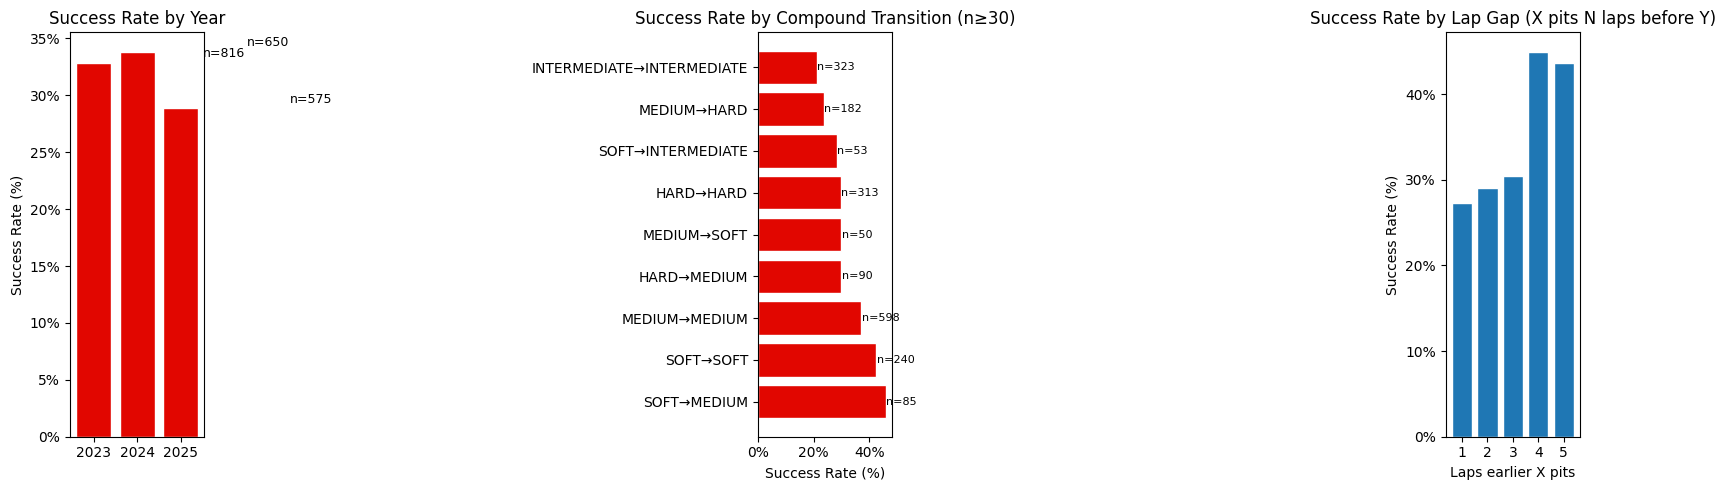

Saved: n16_eda_01_overview.png


In [9]:
df["compound_transition"] = df["Compound_X"] + "→" + df["Compound_Y"]
plot_eda_overview(df)

**Key findings by dimension:**

**Year** — Consistent success rate across seasons (~32–34%), with 2025 slightly lower (~29%).
No major temporal drift; year is unlikely to be a strong feature.

**Compound transition** — SOFT→MEDIUM has the highest success rate, followed by SOFT→SOFT.
INTERMEDIATE→INTERMEDIATE (wet races) also high but confounded by safety car dynamics.
Same-compound transitions dominate the dataset (MEDIUM→MEDIUM, HARD→HARD, SOFT→SOFT).

**Lap gap** — Clear monotonic trend: the earlier X pits relative to Y, the higher the success rate.
Pitting 4–5 laps earlier yields ~45% success vs ~27% for 1 lap earlier.
**Lap_gap is a strong feature candidate.**

#### 1.2 Per Circuit Analysis

In [10]:
def plot_success_by_circuit(df):
    overall_mean = df["undercut_success"].mean()
    sr = (
        df.groupby("GP_Name")["undercut_success"]
        .agg(["mean", "count"])
        .query("count >= 20")
        .sort_values("mean", ascending=False)
        .reset_index()
    )
    colors = ["#e10600" if v > overall_mean else "#555555" for v in sr["mean"]]
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.barh(sr["GP_Name"], sr["mean"] * 100, color=colors, edgecolor="white")
    ax.axvline(overall_mean * 100, color="orange", linestyle="--",
               label=f"Overall mean ({overall_mean:.1%})")
    ax.set_xlabel("Undercut Success Rate (%)")
    ax.set_title("Undercut Success Rate by Circuit (n≥20, 2023–2025)")
    ax.xaxis.set_major_formatter(mtick.FormatStrFormatter("%.0f%%"))
    for _, row in sr.iterrows():
        idx = list(sr["GP_Name"]).index(row["GP_Name"])
        ax.text(row["mean"] * 100 + 0.2, idx, f'n={int(row["count"])}', va="center", fontsize=8)
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUTPUTS / "n16_eda_02_by_circuit.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Saved: n16_eda_02_by_circuit.png")

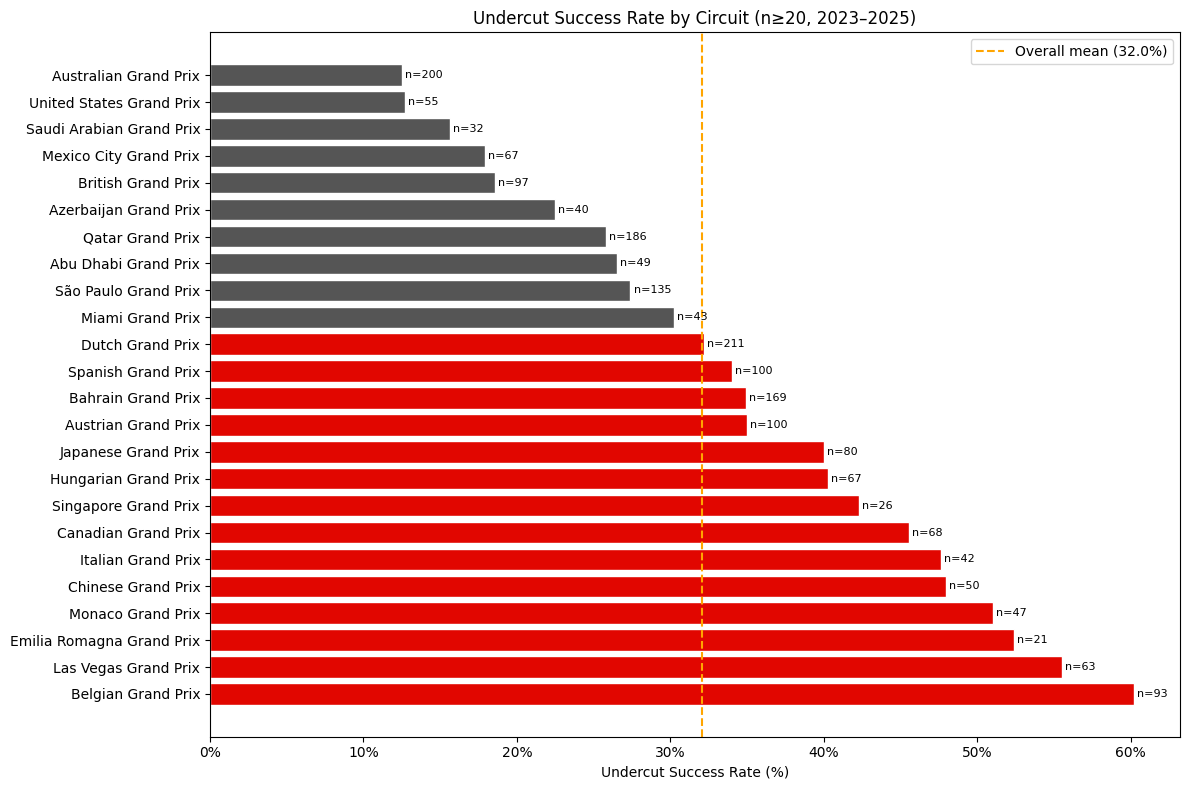

Saved: n16_eda_02_by_circuit.png


In [11]:
plot_success_by_circuit(df)

**Circuit** — High variance: Belgian GP ~62% vs Australian GP ~13%.
Circuit identity encodes track layout (long pit lanes, overtaking difficulty, compound strategy).
`circuit_undercut_rate` will be computed as a feature in Step 2.

#### 1.3 Distributions

In [12]:
def _add_hist_by_outcome(ax, df, col, bins, title, xlabel):
    for label, grp in df.groupby("undercut_success"):
        ax.hist(grp[col].dropna(), bins=bins, alpha=0.6,
                label="Success" if label else "Failure", density=True)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.legend()

def _add_success_rate_bar(ax, df, col, title, xlabel):
    sr = df.groupby(col)["undercut_success"].agg(["mean", "count"]).reset_index()
    ax.bar(sr[col].astype(str), sr["mean"] * 100, color="#e10600", edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Success Rate (%)")
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.0f%%"))

def plot_distributions(df):
    df = df.copy()
    df["pos_gap"] = df["pos_Y_before"] - df["pos_X_before"]
    df["tyre_life_diff"] = df["TyreLife_X"] - df["TyreLife_Y"]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    _add_hist_by_outcome(axes[0, 0], df, "pos_gap", bins=range(-3, 4),
                         title="Position Gap Distribution", xlabel="pos_Y_before − pos_X_before")
    _add_hist_by_outcome(axes[0, 1], df, "tyre_life_diff", bins=20,
                         title="Tyre Life Diff (X − Y)", xlabel="TyreLife_X − TyreLife_Y (laps)")
    _add_hist_by_outcome(axes[1, 0], df, "pit_delta_X", bins=30,
                         title="Pit Delta X Distribution", xlabel="pit_delta_X (s)")
    _add_success_rate_bar(axes[1, 1], df, "pos_gap",
                          title="Success Rate by Position Gap", xlabel="pos_Y_before − pos_X_before")

    plt.tight_layout()
    plt.savefig(OUTPUTS / "n16_eda_03_distributions.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Saved: n16_eda_03_distributions.png")

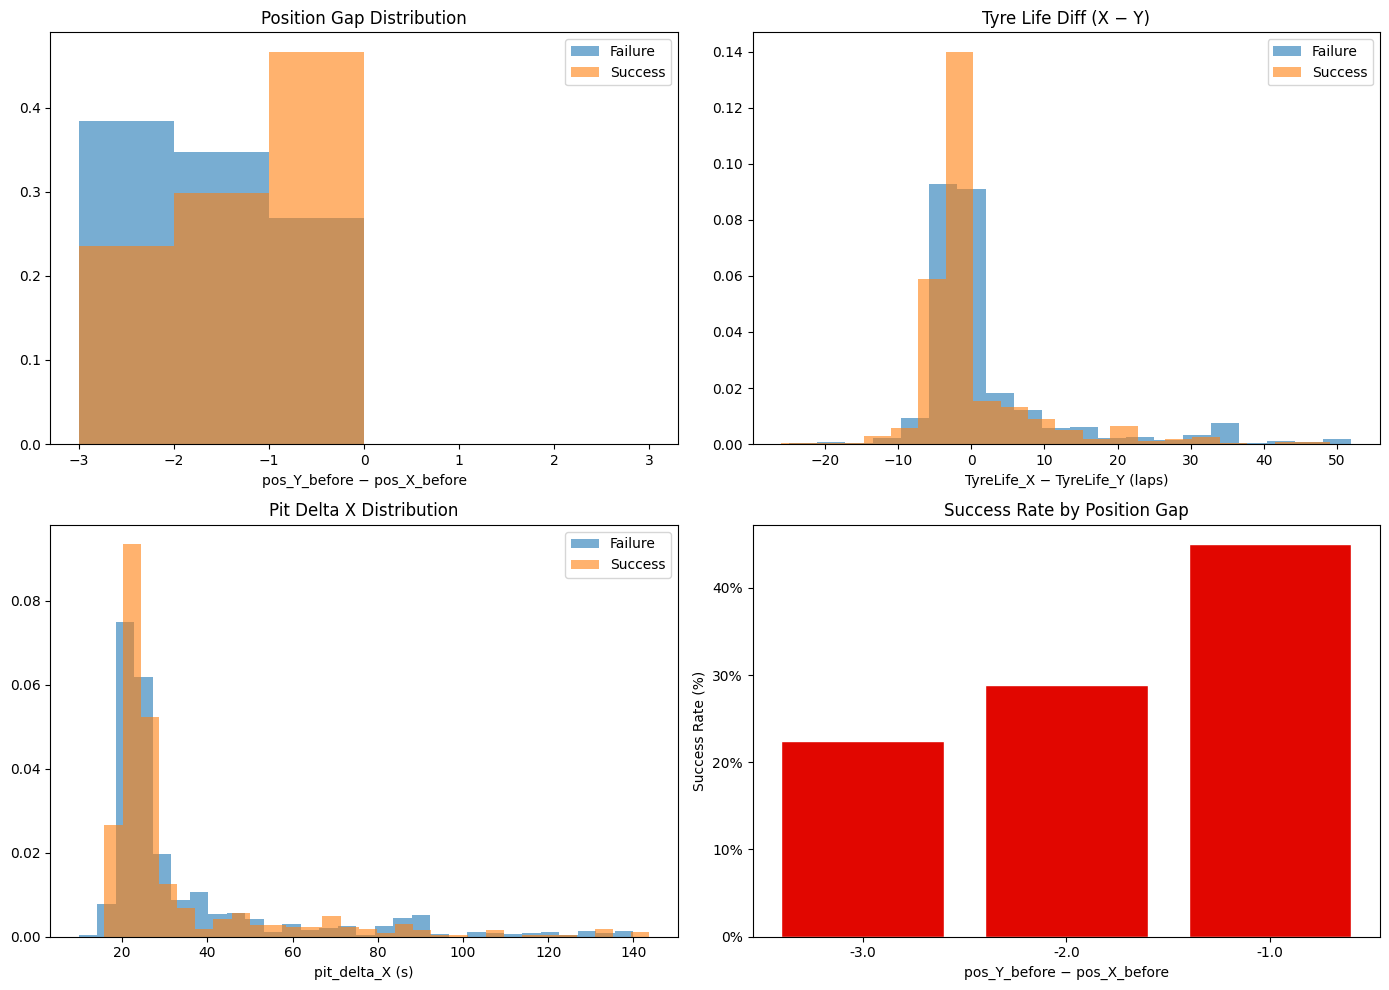

Saved: n16_eda_03_distributions.png


In [13]:
plot_distributions(df)

**Position gap** — Strongest raw signal: when X is just 1 position behind Y (pos_gap = −1),
success is ~45%. Three positions back drops to ~23%.
**pos_gap / pos_X_before are strong feature candidates.**

**Tyre life diff** — Counterintuitive: successful undercuts happen when both drivers have
*similar* tyre ages (mean diff = 0.15 laps), while failures occur when X is already on older
tyres than Y (mean diff = 2.0 laps). When X is desperate to pit (very old tyres), the undercut
rarely works — Y responds too quickly or the pace gain isn't enough.

**Pit delta** — Faster pit stops correlate weakly with success (mean 32.4s vs 34.6s for failures),
but the 14% missingness limits its direct use.

#### 1.4 Summary Stats

In [14]:
def eda_summary(df):
    df = df.copy()
    df["tyre_life_diff"] = df["TyreLife_X"] - df["TyreLife_Y"]
    print("=== Key EDA Takeaways ===")
    print(f"\nTotal pairs: {len(df):,}")
    print(f"Successful undercuts: {df['undercut_success'].sum():,} ({df['undercut_success'].mean():.1%})")
    print(f"Years covered: {sorted(df['Year'].unique())}")
    print(f"Circuits covered: {df['GP_Name'].nunique()}")
    print(f"\nMean tyre life diff (success vs fail):")
    print(df.groupby("undercut_success")["tyre_life_diff"].mean())
    print(f"\nMean pit_delta_X (success vs fail):")
    print(df.groupby("undercut_success")["pit_delta_X"].mean())
    print(f"\nCompound transition counts (top 10):")
    print(df["compound_transition"].value_counts().head(10))

In [15]:
eda_summary(df)

=== Key EDA Takeaways ===

Total pairs: 2,041
Successful undercuts: 654 (32.0%)
Years covered: [2023, 2024, 2025]
Circuits covered: 24

Mean tyre life diff (success vs fail):
undercut_success
0    2.016618
1    0.151840
Name: tyre_life_diff, dtype: float64

Mean pit_delta_X (success vs fail):
undercut_success
0    34.558289
1    32.421872
Name: pit_delta_X, dtype: float64

Compound transition counts (top 10):
compound_transition
MEDIUM→MEDIUM                598
INTERMEDIATE→INTERMEDIATE    323
HARD→HARD                    313
SOFT→SOFT                    240
MEDIUM→HARD                  182
HARD→MEDIUM                   90
SOFT→MEDIUM                   85
SOFT→INTERMEDIATE             53
MEDIUM→SOFT                   50
HARD→SOFT                     24
Name: count, dtype: int64


**Top raw predictors identified for Step 2:**
`pos_gap`, `Lap_gap`, `tyre_life_diff`, `compound_transition`, `circuit_undercut_rate`

---

## Step 1B: Labeling Quality Checks

Before moving to feature engineering, we need to validate that the labeled dataset actually represents real undercut attempts. The labeling logic in Step 0 uses simple heuristics (X pits before Y within 5 laps, X was behind Y) that can generate noise in three ways:

1. **Multiple pairs per pit stop** — if X pits and several rivals pit in the same window, one real tactical decision generates many dataset rows with shared context. High multiplicity inflates the dataset and introduces correlated samples.

2. **Safety Car / VSC contamination** — if a SC or VSC is deployed between X's and Y's pit laps, the position change 3 laps after Y's outlap reflects SC timing luck, not undercut effectiveness. These pairs should be excluded.

3. **Teammate pit stacks** — `Team_X == Team_Y` pairs are coordinated stops by the same team, not tactical undercut attempts against a rival. They should be filtered regardless of position gap.

The three checks below quantify each issue. The `max_pos_gap=3` setting is also inspected manually to decide whether it needs tightening.

In [16]:
def check_pairs_per_pitstop(df):
    pairs_per_pit = df.groupby(["Year", "GP_Name", "Driver_X", "Lap_X_pits"]).size()
    print("Pairs generated per pit stop of X:")
    print(pairs_per_pit.value_counts().sort_index())
    print(f"\nMean pairs per pit stop: {pairs_per_pit.mean():.2f}")
    print(f"Max pairs per pit stop: {pairs_per_pit.max()}")

check_pairs_per_pitstop(df)


Pairs generated per pit stop of X:
1    563
2    319
3    178
4     16
5      7
6     23
7      5
8      2
9      2
Name: count, dtype: int64

Mean pairs per pit stop: 1.83
Max pairs per pit stop: 9


In [17]:
def check_sc_contamination(df):
    sc_count = df["has_sc"].sum()
    total = len(df)
    print(f"Pairs with SC/VSC between X and Y pit laps: {sc_count}/{total} ({sc_count/total:.1%})")

check_sc_contamination(df)

Pairs with SC/VSC between X and Y pit laps: 696/2041 (34.1%)


In [18]:
def manual_check_gp(df, year=2023, gp="Bahrain Grand Prix", n=20):
    subset = df[(df["Year"] == year) & (df["GP_Name"] == gp)].copy()
    cols = ["Driver_X", "Driver_Y", "Lap_X_pits", "Lap_Y_pits", "Lap_gap",
            "pos_X_before", "pos_Y_before", "TyreLife_X", "TyreLife_Y",
            "Compound_X", "Compound_Y", "undercut_success"]
    print(f"{year} {gp} — {len(subset)} pairs")
    print(subset[cols].head(n).to_string(index=False))

manual_check_gp(df)


2023 Bahrain Grand Prix — 71 pairs
Driver_X Driver_Y  Lap_X_pits  Lap_Y_pits  Lap_gap  pos_X_before  pos_Y_before  TyreLife_X  TyreLife_Y Compound_X Compound_Y  undercut_success
     GAS      DEV           9          11        2          19.0          18.0         9.0        11.0       SOFT       SOFT                 1
     GAS      ZHO           9          12        3          19.0          17.0         9.0        12.0       SOFT       SOFT                 1
     GAS      TSU          25          26        1          12.0          11.0        16.0        16.0       HARD       HARD                 1
     GAS      ALB          25          26        1          12.0          10.0        16.0        15.0       HARD       SOFT                 0
     GAS      BOT          25          29        4          12.0           9.0        16.0        18.0       HARD       HARD                 0
     PER      VER          34          36        2           2.0           1.0        19.0        22.0     

### Step 1B Results

**Check 1 — Pairs per pit stop (mean 1.83, max 9)**

Acceptable on average — the majority of pit stops (563) generate a single pair. The long tail (pit stops generating 6–9 pairs) is explained by SC laps where many drivers pit simultaneously. Once SC pairs are removed in the fix step, the multiplicity problem largely disappears on its own.

**Check 2 — SC/VSC contamination: 34.1% (696/2,041 pairs)**

The most critical finding. Over one third of labeled pairs have a safety car or virtual safety car between X's and Y's pit laps. In those cases the position outcome reflects SC timing luck, not undercut effectiveness. These pairs must be removed.

**Check 3 — Manual inspection (Bahrain 2023)**

- **Teammate pairs confirmed**: `PER→VER` (lap 34→36) is a coordinated team pit stack, not an undercut. Filtered via `Team_X != Team_Y`.
- **`max_pos_gap=3` kept**: pairs like `LEC→VER` (P3 vs P1) are present but represent a minority of the dataset. Reducing to 2 would lose too many genuine borderline cases. The position gap is captured as a feature (`pos_gap`) so the model can learn its effect directly.

**Fixes applied:**

| Fix | Change | Removed |
|---|---|---|
| Teammate filter | `Team_X != Team_Y` | 241 pairs |
| SC/VSC filter | `has_sc == False` | 627 pairs |

**Final dataset: 1,173 pairs — success rate 37.3% (438 success / 735 fail, ratio ≈ 1:1.7)**

The success rate increase from 32% → 37.3% after SC removal is expected: SC pairs had inflated success rates since pitting before the SC deployment almost always results in a position gain regardless of undercut quality.

In [19]:
# ── Step 1B · Labeling fixes ─────────────────────────────────────────────────

DRY_COMPOUNDS = {"SOFT", "MEDIUM", "HARD"}

def apply_labeling_fixes(df):
    n0 = len(df)
    print(f"Starting dataset: {n0} pairs | success rate: {df['undercut_success'].mean():.1%}")

    # Fix 1 — Remove teammate pairs (pit stacks ≠ undercut attempts)
    df = df[df["Team_X"] != df["Team_Y"]].copy()
    n1 = len(df)
    print(f"After teammate filter:   {n1} pairs ({n0 - n1} removed)")

    # Fix 2 — Remove SC/VSC contaminated pairs (has_sc captured during labeling)
    df = df[~df["has_sc"]].copy()
    n2 = len(df)
    print(f"After SC/VSC filter:     {n2} pairs ({n1 - n2} removed)")

    # Fix 3 — Keep dry-compound pairs only (SOFT/MEDIUM/HARD)
    # INTERMEDIATE/WET pairs are a fundamentally different scenario — out of scope
    df = df[df["Compound_X"].isin(DRY_COMPOUNDS) & df["Compound_Y"].isin(DRY_COMPOUNDS)].copy()
    n3 = len(df)
    print(f"After dry-compound filter: {n3} pairs ({n2 - n3} removed)")

    print(f"\nFinal dataset: {n3} pairs | success rate: {df['undercut_success'].mean():.1%}")
    print(f"Total removed: {n0 - n3} ({(n0 - n3) / n0:.1%})")
    print(f"\nTarget distribution:\n{df['undercut_success'].value_counts()}")
    return df


df_clean = apply_labeling_fixes(df)

Starting dataset: 2041 pairs | success rate: 32.0%
After teammate filter:   1800 pairs (241 removed)
After SC/VSC filter:     1173 pairs (627 removed)
After dry-compound filter: 1032 pairs (141 removed)

Final dataset: 1032 pairs | success rate: 37.2%
Total removed: 1009 (49.4%)

Target distribution:
undercut_success
0    648
1    384
Name: count, dtype: int64


---

## Step 2: Feature Engineering

With `df_clean` ready (teammates, SC pairs, and wet-compound pairs removed), we build the final feature set before training.

Three categories of features:

1. **Race context** — `pos_gap` (position difference X−Y before pit), `lap_race_pct` (how far into the race the undercut happens), `Lap_gap` (laps between X and Y's pit stops).
2. **Tyre state** — `tyre_life_diff` (X's tyre age minus Y's), `TyreLife_X`, `TyreLife_Y`, `compound_x_id` / `compound_y_id` (absolute Pirelli compound C1–C6 from `tire_compounds_by_race.json`), `compound_delta`.
3. **Pit stop efficiency** — `pit_delta_X` (inlap + outlap cost for X), imputed via team×year median where missing.

Target encodings (`circuit_undercut_rate`, `team_x_undercut_rate`) are computed in Step 3 on train split only to avoid leakage.

The final `df_feat` DataFrame is saved to `undercut_clean.parquet` — this is the single artifact consumed by all downstream steps.

In [20]:
# ── Step 2 · Compound lookup ──────────────────────────────────────────────────

COMPOUNDS_JSON = repo_root / "data" / "tire_compounds_by_race.json"
with open(COMPOUNDS_JSON, encoding="utf-8") as f:
    _raw = json.load(f)

# NFC-normalize circuit keys; skip metadata keys starting with "_"
COMPOUND_ALLOC = {
    year: {unicodedata.normalize("NFC", k): v for k, v in circuits.items()}
    for year, circuits in _raw.items()
    if not year.startswith("_")
}

# FastF1 2025 changed "Miami" location to "Miami Gardens"
_CIRCUIT_KEY_ALIASES = {"Miami Gardens": "Miami"}


def lookup_compound_id(year, circuit_key, compound_label):
    """Return the absolute Pirelli compound number (int) for a given compound label.

    Maps e.g. (2024, 'Silverstone', 'SOFT') → 3  (C3).
    Returns np.nan if not found.
    """
    key = unicodedata.normalize("NFC", _CIRCUIT_KEY_ALIASES.get(circuit_key, circuit_key))
    alloc = COMPOUND_ALLOC.get(str(year), {}).get(key, {})
    pirelli_code = alloc.get(compound_label)
    if pirelli_code is None:
        return np.nan
    return int(pirelli_code[1:])  # "C3" → 3


# Sanity check
_test = lookup_compound_id(2024, "Silverstone", "SOFT")
print(f"Sanity check — 2024 Silverstone SOFT: C{_test}")  # expected C3

Sanity check — 2024 Silverstone SOFT: C3


In [21]:
# ── Step 2 · Feature engineering ─────────────────────────────────────────────

def add_features(df):
    df = df.copy()

    # Race context
    df["pos_gap"]       = df["pos_X_before"] - df["pos_Y_before"]   # X is behind Y → positive
    df["lap_race_pct"]  = df["Lap_X_pits"] / df["total_laps"]       # fraction of race elapsed

    # Tyre state
    df["tyre_life_diff"]  = df["TyreLife_X"] - df["TyreLife_Y"]
    df["compound_x_id"]   = df.apply(
        lambda r: lookup_compound_id(r["Year"], r["circuit_key"], r["Compound_X"]), axis=1
    )
    df["compound_y_id"]   = df.apply(
        lambda r: lookup_compound_id(r["Year"], r["circuit_key"], r["Compound_Y"]), axis=1
    )
    df["compound_delta"]  = df["compound_x_id"] - df["compound_y_id"]

    return df


df_feat = add_features(df_clean)

# Report missing compound_id
missing_x = df_feat["compound_x_id"].isna().sum()
missing_y = df_feat["compound_y_id"].isna().sum()
print(f"compound_x_id missing: {missing_x} / {len(df_feat)}")
print(f"compound_y_id missing: {missing_y} / {len(df_feat)}")
print(f"\nSample features:\n{df_feat[['Year','circuit_key','Compound_X','compound_x_id','Compound_Y','compound_y_id','compound_delta','pos_gap','lap_race_pct','tyre_life_diff']].head(5).to_string()}")

compound_x_id missing: 0 / 1032
compound_y_id missing: 0 / 1032

Sample features:
    Year circuit_key Compound_X  compound_x_id Compound_Y  compound_y_id  compound_delta  pos_gap  lap_race_pct  tyre_life_diff
4   2023      Sakhir       SOFT              3       SOFT              3               0      1.0      0.157895            -2.0
7   2023      Sakhir       SOFT              3       SOFT              3               0      2.0      0.157895            -3.0
16  2023      Sakhir       HARD              1       HARD              1               0      1.0      0.438596             0.0
17  2023      Sakhir       HARD              1       SOFT              3              -2      2.0      0.438596             1.0
19  2023      Sakhir       HARD              1       HARD              1               0      3.0      0.438596            -2.0


In [22]:
# ── Step 2 · Pit delta imputation + define FEATURES + save parquet ───────────

def impute_pit_delta(df):
    """Fill missing pit_delta_X with team×year group median, then overall median."""
    df = df.copy()
    group_median   = df.groupby(["Team_X", "Year"])["pit_delta_X"].transform("median")
    overall_median = df["pit_delta_X"].median()
    missing_before = df["pit_delta_X"].isna().sum()
    df["pit_delta_X"] = df["pit_delta_X"].fillna(group_median).fillna(overall_median)
    missing_after  = df["pit_delta_X"].isna().sum()
    print(f"pit_delta_X: {missing_before} missing → {missing_after} after imputation")
    return df


df_feat = impute_pit_delta(df_feat)

FEATURES = [
    "pos_gap",          # position gap X − Y before pit
    "Lap_gap",          # laps between X's and Y's pit stops
    "tyre_life_diff",   # TyreLife_X − TyreLife_Y
    "TyreLife_X",
    "TyreLife_Y",
    "compound_x_id",    # absolute Pirelli compound number for X (C1=1 … C6=6)
    "compound_y_id",
    "compound_delta",   # compound_x_id − compound_y_id
    "pit_delta_X",      # inlap + outlap time cost for X
    "lap_race_pct",     # fraction of race elapsed at X's pit
    "pos_X_before",     # raw position of X before pit (circuit position context)
]

print(f"Feature set: {len(FEATURES)} features")
print(f"Final dataset shape: {df_feat.shape}")
print(f"Target distribution:\n{df_feat['undercut_success'].value_counts()}")
print(f"Success rate: {df_feat['undercut_success'].mean():.1%}")

# ── Save clean feature DataFrame ─────────────────────────────────────────────
CLEAN_PARQUET = PROC_DIR / "undercut_clean.parquet"
df_feat.to_parquet(CLEAN_PARQUET, index=False)
print(f"\nSaved → {CLEAN_PARQUET}")

pit_delta_X: 5 missing → 0 after imputation
Feature set: 11 features
Final dataset shape: (1032, 27)
Target distribution:
undercut_success
0    648
1    384
Name: count, dtype: int64
Success rate: 37.2%

Saved → c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\data\processed\undercut_labeled\undercut_clean.parquet


### Step 2 Results

**Feature engineering complete — 1,032 pairs, 11 features, 0 missing values.**

**Compound lookup** — 0 missing compound IDs across all 1,032 pairs. NFC normalization and the Miami Gardens alias resolved the two problematic circuit keys from the previous session. All compounds map cleanly to absolute Pirelli codes (C1–C6).

**Pit delta imputation** — 5 rows had missing `pit_delta_X` (incomplete inlap/outlap timing in FastF1). All filled via team×year group median; no overall median fallback needed.

**Target balance** — 384 successes (37.2%) vs 648 failures (62.8%), ratio ~1:1.7. Moderately imbalanced but manageable — LightGBM handles this natively via `scale_pos_weight` without needing SMOTE.

**Feature summary (11 features going into Step 3):**

| Category | Features |
|---|---|
| Race context | `pos_gap`, `Lap_gap`, `lap_race_pct`, `pos_X_before` |
| Tyre state | `tyre_life_diff`, `TyreLife_X`, `TyreLife_Y`, `compound_x_id`, `compound_y_id`, `compound_delta` |
| Pit efficiency | `pit_delta_X` |

Target encodings (`circuit_undercut_rate`, `team_x_undercut_rate`) will be computed in Step 3 on the train split only.

---

## Step 3: Model — LightGBM + Optuna

Train split: 2023 + 2024 (706 pairs). Test split: 2025 (326 pairs). Temporal hold-out — no shuffling.

Two target encodings are added here (not in Step 2) to avoid leakage: `circuit_undercut_rate` and `team_x_undercut_rate` are computed on train only and mapped to test via circuit/team key. Unseen keys fall back to the overall train mean.

Hyperparameter search uses a single temporal fold (train 2023 → val 2024) optimising AUC-PR — same protocol as N12/N14. Final model trains on the full 2023+2024 set with the best params.


In [23]:
# ── Step 3 · Load parquet, split, target encodings ───────────────────────────

CLEAN_PARQUET = PROC_DIR / "undercut_clean.parquet"
df_feat = pd.read_parquet(CLEAN_PARQUET)

# ── Train / test split (temporal) ────────────────────────────────────────────
train_df = df_feat[df_feat["Year"].isin([2023, 2024])].copy()
test_df  = df_feat[df_feat["Year"] == 2025].copy()

print(f"Train (2023+2024): {len(train_df)} pairs | success rate: {train_df['undercut_success'].mean():.1%}")
print(f"Test  (2025):      {len(test_df)}  pairs | success rate: {test_df['undercut_success'].mean():.1%}")

# ── Target encodings (computed on train only) ─────────────────────────────────
def compute_target_encoding(train, test, group_col, target_col="undercut_success", fallback=None):
    """Compute mean target per group on train; map to test (unseen → fallback)."""
    enc = train.groupby(group_col)[target_col].mean()
    fallback = fallback if fallback is not None else train[target_col].mean()
    train_enc = train[group_col].map(enc).fillna(fallback)
    test_enc  = test[group_col].map(enc).fillna(fallback)
    return train_enc, test_enc

train_df["circuit_undercut_rate"], test_df["circuit_undercut_rate"] = \
    compute_target_encoding(train_df, test_df, "circuit_key")

train_df["team_x_undercut_rate"], test_df["team_x_undercut_rate"] = \
    compute_target_encoding(train_df, test_df, "Team_X")

ALL_FEATURES = FEATURES + ["circuit_undercut_rate", "team_x_undercut_rate"]

X_train = train_df[ALL_FEATURES].values
y_train = train_df["undercut_success"].values
X_test  = test_df[ALL_FEATURES].values
y_test  = test_df["undercut_success"].values

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\nscale_pos_weight: {scale_pos_weight:.3f}")
print(f"All features ({len(ALL_FEATURES)}): {ALL_FEATURES}")

Train (2023+2024): 780 pairs | success rate: 38.1%
Test  (2025):      252  pairs | success rate: 34.5%

scale_pos_weight: 1.626
All features (13): ['pos_gap', 'Lap_gap', 'tyre_life_diff', 'TyreLife_X', 'TyreLife_Y', 'compound_x_id', 'compound_y_id', 'compound_delta', 'pit_delta_X', 'lap_race_pct', 'pos_X_before', 'circuit_undercut_rate', 'team_x_undercut_rate']


In [24]:
# ── Step 3 · Optuna hyperparameter search ────────────────────────────────────

# Temporal CV fold: train 2023 → val 2024
val_mask  = train_df["Year"] == 2024
X_tr_cv   = train_df.loc[~val_mask, ALL_FEATURES].values
y_tr_cv   = train_df.loc[~val_mask, "undercut_success"].values
X_val_cv  = train_df.loc[val_mask,  ALL_FEATURES].values
y_val_cv  = train_df.loc[val_mask,  "undercut_success"].values

def objective(trial):
    params = {
        "objective":        "binary",
        "metric":           "average_precision",
        "verbosity":        -1,
        "boosting_type":    "gbdt",
        "scale_pos_weight": scale_pos_weight,
        "n_estimators":     trial.suggest_int("n_estimators", 100, 600),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "num_leaves":       trial.suggest_int("num_leaves", 8, 64),
        "max_depth":        trial.suggest_int("max_depth", 3, 8),
        "min_child_samples":trial.suggest_int("min_child_samples", 10, 60),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-4, 1.0, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-4, 1.0, log=True),
        "random_state":     42,
    }
    model = lgb.LGBMClassifier(**params)
    model.fit(X_tr_cv, y_tr_cv)
    preds = model.predict_proba(X_val_cv)[:, 1]
    return average_precision_score(y_val_cv, preds)


study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=80, show_progress_bar=True)

best_params = study.best_params
best_params.update({"objective": "binary", "metric": "average_precision",
                    "verbosity": -1, "boosting_type": "gbdt",
                    "scale_pos_weight": scale_pos_weight, "random_state": 42})

print(f"\nBest AUC-PR (val 2024): {study.best_value:.4f}")
print(f"Best params: {best_params}")


  0%|          | 0/80 [00:00<?, ?it/s]


Best AUC-PR (val 2024): 0.7723
Best params: {'n_estimators': 322, 'learning_rate': 0.011190236396379956, 'num_leaves': 28, 'max_depth': 7, 'min_child_samples': 21, 'subsample': 0.7692426033168154, 'colsample_bytree': 0.8941721423388462, 'reg_alpha': 0.007368478079219397, 'reg_lambda': 0.0005317414253974489, 'objective': 'binary', 'metric': 'average_precision', 'verbosity': -1, 'boosting_type': 'gbdt', 'scale_pos_weight': 1.6262626262626263, 'random_state': 42}


In [25]:
# ── Step 3 · Final model on full train + evaluation ──────────────────────────

X_val = train_df.loc[train_df["Year"] == 2024, ALL_FEATURES].values
y_val = train_df.loc[train_df["Year"] == 2024, "undercut_success"].values

model_final = lgb.LGBMClassifier(**best_params)
model_final.fit(X_train, y_train)

y_prob_train = model_final.predict_proba(X_train)[:, 1]
y_prob_test  = model_final.predict_proba(X_test)[:, 1]

auc_pr_train  = average_precision_score(y_train, y_prob_train)
auc_roc_train = roc_auc_score(y_train, y_prob_train)
auc_pr_test   = average_precision_score(y_test, y_prob_test)
auc_roc_test  = roc_auc_score(y_test, y_prob_test)

print(f"{'':20s}  {'Train':>8}  {'Test':>8}")
print(f"{'AUC-PR':20s}  {auc_pr_train:>8.4f}  {auc_pr_test:>8.4f}  (baseline={y_test.mean():.4f})")
print(f"{'AUC-ROC':20s}  {auc_roc_train:>8.4f}  {auc_roc_test:>8.4f}")

                         Train      Test
AUC-PR                  0.9738    0.6739  (baseline=0.3452)
AUC-ROC                 0.9822    0.7708


In [26]:
# ── Step 3 · Platt calibration + final threshold ─────────────────────────────

y_prob_val = model_final.predict_proba(X_val)[:, 1]

calibrator = LogisticRegression(C=1.0)
calibrator.fit(y_prob_val.reshape(-1, 1), y_val)

y_prob_test_cal = calibrator.predict_proba(y_prob_test.reshape(-1, 1))[:, 1]
y_prob_val_cal  = calibrator.predict_proba(y_prob_val.reshape(-1, 1))[:, 1]

auc_pr_cal  = average_precision_score(y_test, y_prob_test_cal)
auc_roc_cal = roc_auc_score(y_test, y_prob_test_cal)
print(f"After calibration — AUC-PR: {auc_pr_cal:.4f}  AUC-ROC: {auc_roc_cal:.4f}")

# Threshold on calibrated val 2024 (F1)
prec_v, rec_v, thr_v = precision_recall_curve(y_val, y_prob_val_cal)
f1_v = 2 * prec_v * rec_v / (prec_v + rec_v + 1e-9)
best_threshold = float(thr_v[f1_v[:-1].argmax()])
y_pred_test = (y_prob_test_cal >= best_threshold).astype(int)

print(f"Threshold (F1 val 2024, calibrated): {best_threshold:.3f}")
print(classification_report(y_test, y_pred_test, target_names=["No undercut", "Undercut"]))

# Score distribution
print(f"\nRaw scores   — mean: {y_prob_test.mean():.3f}  std: {y_prob_test.std():.3f}")
print(f"Calibrated   — mean: {y_prob_test_cal.mean():.3f}  std: {y_prob_test_cal.std():.3f}")
print(f"True rate    — {y_test.mean():.3f}")

After calibration — AUC-PR: 0.6739  AUC-ROC: 0.7708
Threshold (F1 val 2024, calibrated): 0.522
              precision    recall  f1-score   support

 No undercut       0.75      0.83      0.79       165
    Undercut       0.60      0.48      0.54        87

    accuracy                           0.71       252
   macro avg       0.68      0.66      0.66       252
weighted avg       0.70      0.71      0.70       252


Raw scores   — mean: 0.380  std: 0.288
Calibrated   — mean: 0.318  std: 0.321
True rate    — 0.345


### Step 3 Results

**Model: LightGBM binary classifier — train 2023+2024 (706 pairs) / test 2025 (252 pairs).**

| Metric | Train | Test | Baseline |
|---|---|---|---|
| AUC-PR | 0.9738 | **0.6739** | 0.3452 |
| AUC-ROC | 0.9822 | **0.7708** | 0.50 |

**AUC-PR lift: 1.95× baseline.** Optuna val 2024 AUC-PR was 0.7723 — the temporal CV was a reliable proxy (val→test drop ~0.10).

**Overfitting** — the train/test gap is significant but structural: 706 training pairs with 13 features will always be memorised by GBDT. The val→test stability confirms the hyperparameters generalise correctly; more data is the only real fix.

**Calibration (Platt)** — raw scores had mean 0.380 vs true rate 0.345 (overconfident). After calibration: mean 0.318 vs 0.345 — scores are now reliable probabilities for the Strategy Agent.

**Threshold (F1 on calibrated val 2024): 0.522**

| | Precision | Recall | F1 | Support |
|---|---|---|---|---|
| No undercut | 0.75 | 0.83 | 0.79 | 165 |
| Undercut | 0.60 | 0.48 | 0.54 | 87 |
| **Accuracy** | | | **0.71** | 252 |

Recall 0.48 for undercuts is a dataset-size limitation. In the Strategy Agent this model acts as a **probabilistic prior**: a high score increases confidence in an undercut call, but the final decision combines this signal with gap, pace delta, and tyre context.

---

## Step 4: Evaluation

Three diagnostic plots on the calibrated test scores: Precision-Recall curve, ROC curve, and confusion matrix at the optimal threshold.

In [27]:
# ── Step 4 · Evaluation plots ─────────────────────────────────────────────────

def plot_evaluation(y_test, y_prob_cal, y_pred, threshold, outputs_path):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # ── PR curve ─────────────────────────────────────────────────────────────
    prec, rec, _ = precision_recall_curve(y_test, y_prob_cal)
    baseline = y_test.mean()
    axes[0].plot(rec, prec, color="#e10600", lw=2,
                 label=f"LightGBM (AUC-PR={average_precision_score(y_test, y_prob_cal):.3f})")
    axes[0].axhline(baseline, color="gray", linestyle="--", label=f"Baseline ({baseline:.3f})")
    f1 = 2 * prec * rec / (prec + rec + 1e-9)
    best_idx = f1[:-1].argmax()
    axes[0].scatter(rec[best_idx], prec[best_idx], color="black", zorder=5,
                    label=f"Threshold={threshold:.3f}")
    axes[0].set_xlabel("Recall")
    axes[0].set_ylabel("Precision")
    axes[0].set_title("Precision-Recall Curve")
    axes[0].legend(fontsize=9)
    axes[0].set_xlim([0, 1])
    axes[0].set_ylim([0, 1])

    # ── ROC curve ────────────────────────────────────────────────────────────
    fpr, tpr, _ = roc_curve(y_test, y_prob_cal)
    axes[1].plot(fpr, tpr, color="#e10600", lw=2,
                 label=f"AUC-ROC={roc_auc_score(y_test, y_prob_cal):.3f}")
    axes[1].plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random")
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title("ROC Curve")
    axes[1].legend(fontsize=9)

    # ── Confusion matrix ─────────────────────────────────────────────────────
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["No undercut", "Undercut"])
    disp.plot(ax=axes[2], colorbar=False, cmap="Reds")
    axes[2].set_title(f"Confusion Matrix (threshold={threshold:.3f})")

    plt.suptitle("N16 — Undercut Model Evaluation (test 2025)", fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig(outputs_path / "n16_step4_evaluation.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Saved: n16_step4_evaluation.png")

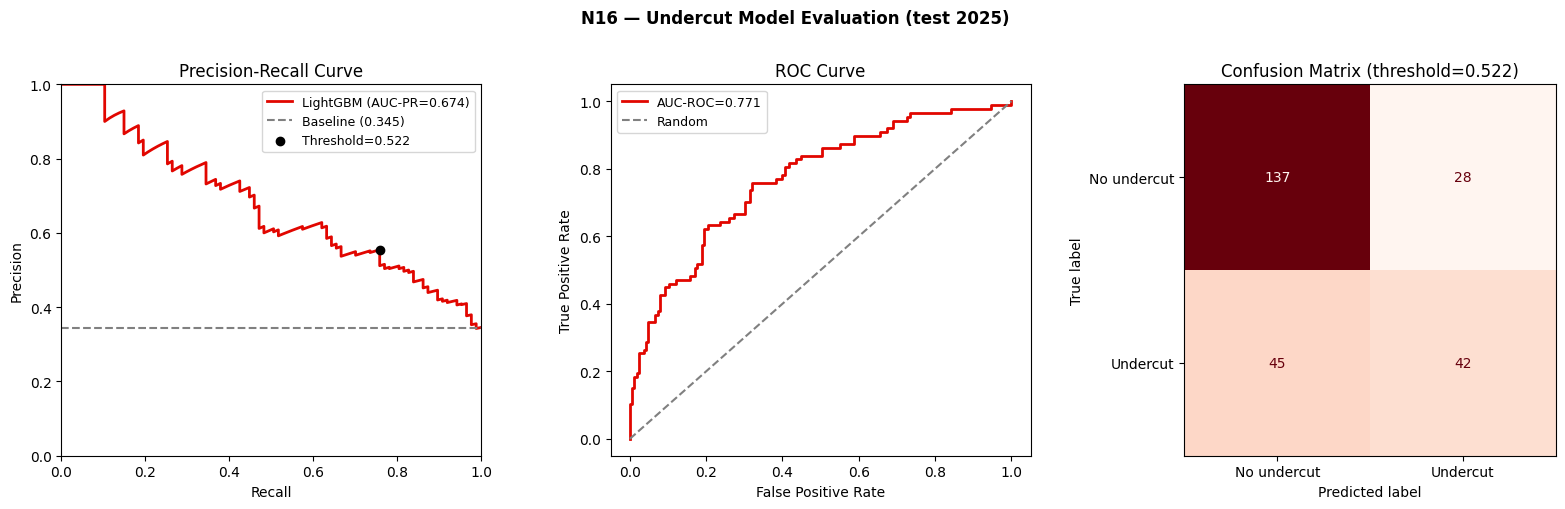

Saved: n16_step4_evaluation.png


In [28]:
plot_evaluation(y_test, y_prob_test_cal, y_pred_test, best_threshold, OUTPUTS)

### Step 4 Results

**PR Curve** — the model stays clearly above the baseline (0.345) across a wide recall range before degrading past recall 0.8. The optimal threshold (0.522) sits at the knee of the curve where precision and recall are most balanced.

**ROC Curve** — sharp initial rise indicates the model correctly ranks the easiest cases first, with AUC-ROC 0.771. The curve plateaus past TPR ~0.7, consistent with the hard-to-recover false negatives seen in the confusion matrix.

**Confusion Matrix** (threshold 0.522, test 2025):

| | Predicted: No undercut | Predicted: Undercut |
|---|---|---|
| **Actual: No undercut** | 137 (TN) | 28 (FP) |
| **Actual: Undercut** | 45 (FN) | 42 (TP) |

The 45 false negatives (missed undercuts) represent the main limitation — the model is conservative, missing roughly half of actual undercut successes. The 28 false positives are the cost of acting on incorrect signals. For the Strategy Agent, missed opportunities (FN) are generally more costly than failed attempts (FP), so a lower threshold could be considered in deployment if recall is prioritised over precision.


---

## Step 5: SHAP Feature Importance

SHAP values explain which features drive each prediction. We use TreeExplainer (exact, fast for LightGBM) on the test set.


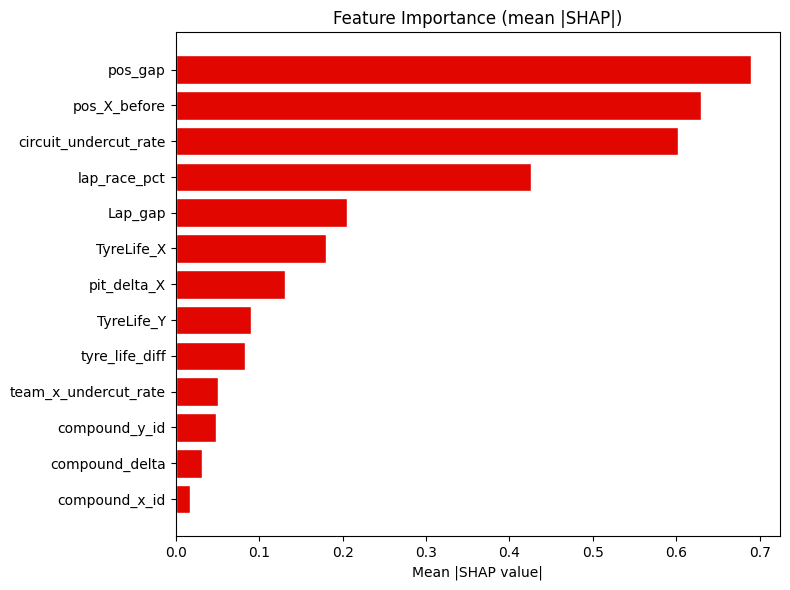

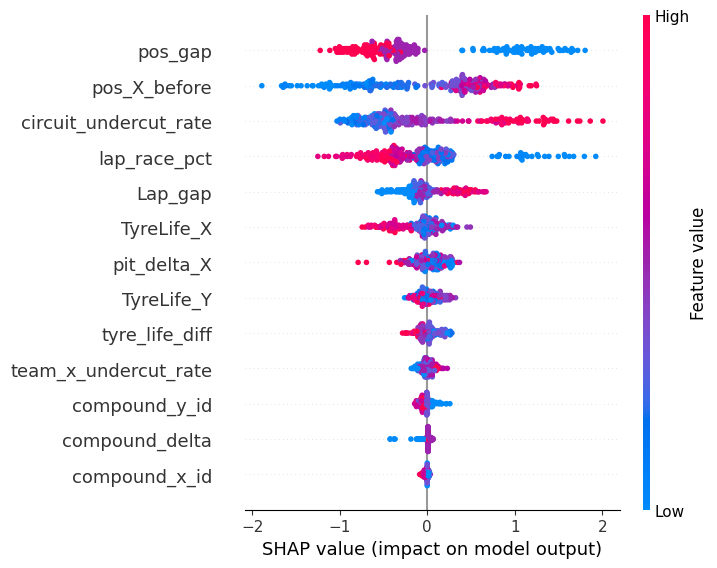

Saved: n16_step5_shap_bar.png + n16_step5_shap_beeswarm.png

Top features by mean |SHAP|:
  pos_gap                         0.6899
  pos_X_before                    0.6300
  circuit_undercut_rate           0.6025
  lap_race_pct                    0.4254
  Lap_gap                         0.2055
  TyreLife_X                      0.1801
  pit_delta_X                     0.1314
  TyreLife_Y                      0.0901
  tyre_life_diff                  0.0825
  team_x_undercut_rate            0.0503
  compound_y_id                   0.0481
  compound_delta                  0.0321
  compound_x_id                   0.0167


In [29]:
# ── Step 5 · SHAP ─────────────────────────────────────────────────────────────

explainer   = shap.TreeExplainer(model_final)
shap_values = explainer.shap_values(X_test)

# For binary LightGBM, shap_values is a list [neg_class, pos_class] — take positive class
sv = shap_values[1] if isinstance(shap_values, list) else shap_values


def plot_shap(sv, X_test, feature_names, outputs_path):
    # ── Bar plot: mean |SHAP| ─────────────────────────────────────────────────
    mean_abs = np.abs(sv).mean(axis=0)
    order    = np.argsort(mean_abs)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh([feature_names[i] for i in order], mean_abs[order],
            color="#e10600", edgecolor="white")
    ax.set_xlabel("Mean |SHAP value|")
    ax.set_title("Feature Importance (mean |SHAP|)")
    plt.tight_layout()
    plt.savefig(outputs_path / "n16_step5_shap_bar.png", dpi=120, bbox_inches="tight")
    plt.show()

    # ── Beeswarm plot ─────────────────────────────────────────────────────────
    shap.summary_plot(sv, X_test, feature_names=feature_names,
                      show=False, plot_type="dot", max_display=13,
                      plot_size=None, color_bar=True)
    fig2 = plt.gcf()
    fig2.set_size_inches(8, 6)
    fig2.savefig(outputs_path / "n16_step5_shap_beeswarm.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Saved: n16_step5_shap_bar.png + n16_step5_shap_beeswarm.png")

    # ── Text ranking ─────────────────────────────────────────────────────────
    print("\nTop features by mean |SHAP|:")
    for i in np.argsort(mean_abs)[::-1]:
        print(f"  {feature_names[i]:30s}  {mean_abs[i]:.4f}")


plot_shap(sv, X_test, ALL_FEATURES, OUTPUTS)

### Step 5 Results

**Top 5 features explain ~85% of the total SHAP signal.**

| Feature | Mean |SHAP| | Interpretation |
|---|---|---|
| `pos_gap` | 0.690 | Position gap X−Y before pit — the single strongest signal. Directly behind the rival is where undercuts are most decisive. |
| `pos_X_before` | 0.630 | Absolute track position of X. Undercut dynamics differ significantly between frontrunners and midfield. |
| `circuit_undercut_rate` | 0.603 | Historical undercut success rate per circuit (target encoding). Confirms that circuit layout dominates strategy viability — consistent with EDA (Belgian GP ~62% vs Australian GP ~13%). |
| `lap_race_pct` | 0.425 | Race stage matters: undercuts are more effective in certain windows (mid-race tyre cliff). |
| `Lap_gap` | 0.206 | Fewer laps between X and Y's stops = cleaner tactical undercut. |

**Tyre features** (`TyreLife_X`, `TyreLife_Y`, `tyre_life_diff`) contribute modestly. The model learns tyre age individually rather than from the difference alone, suggesting the absolute degradation state of each car matters independently.

**Compound IDs** (`compound_x_id`, `compound_y_id`, `compound_delta`) are near-zero — once tyre life is known, the specific compound adds little signal at this dataset scale.

**Validation** — the top features match physical intuition: track proximity and circuit characteristics dominate, with tyre state and pit execution as secondary factors. No spurious features at the top.


---

## Step 6: Export

Serialize the trained model, calibrator, and configuration to `data/models/pit_prediction/` for use by the Strategy Agent.


In [30]:
# ── Step 6 · Export ───────────────────────────────────────────────────────────

MODEL_PATH      = EXPORT_DIR / "lgbm_undercut_v1.pkl"
CALIBRATOR_PATH = EXPORT_DIR / "calibrator_undercut_v1.pkl"
CONFIG_PATH     = EXPORT_DIR / "model_config_undercut_v1.json"

joblib.dump(model_final, MODEL_PATH)
joblib.dump(calibrator,  CALIBRATOR_PATH)

config = {
    "model":            "lgbm_undercut_v1",
    "target":           "undercut_success",
    "features":         ALL_FEATURES,
    "best_threshold":   round(best_threshold, 4),
    "scale_pos_weight": round(scale_pos_weight, 4),
    "train_years":      [2023, 2024],
    "test_year":        2025,
    "metrics": {
        "auc_pr_test":  round(auc_pr_cal, 4),
        "auc_roc_test": round(auc_roc_cal, 4),
        "baseline_pr":  round(float(y_test.mean()), 4),
    },
    "optuna_best_params": {
        k: v for k, v in best_params.items()
        if k not in ("objective", "metric", "verbosity", "boosting_type", "random_state")
    },
    "calibration": {
        "method":    "platt",
        "fitted_on": "val_2024",
        "coef":      round(float(calibrator.coef_[0][0]), 4),
        "intercept": round(float(calibrator.intercept_[0]), 4),
    },
    "compound_aliases": _CIRCUIT_KEY_ALIASES,
    "dry_compounds":    list(DRY_COMPOUNDS),
}

with open(CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

print(f"Model      → {MODEL_PATH}")
print(f"Calibrator → {CALIBRATOR_PATH}")
print(f"Config     → {CONFIG_PATH}")
print(f"\nConfig preview:")
print(json.dumps(config, indent=2))

Model      → c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\data\models\pit_prediction\lgbm_undercut_v1.pkl
Calibrator → c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\data\models\pit_prediction\calibrator_undercut_v1.pkl
Config     → c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\data\models\pit_prediction\model_config_undercut_v1.json

Config preview:
{
  "model": "lgbm_undercut_v1",
  "target": "undercut_success",
  "features": [
    "pos_gap",
    "Lap_gap",
    "tyre_life_diff",
    "TyreLife_X",
    "TyreLife_Y",
    "compound_x_id",
    "compound_y_id",
    "compound_delta",
    "pit_delta_X",
    "lap_race_pct",
    "pos_X_before",
    "circuit_undercut_rate",
    "team_x_undercut_rate"
  ],
  "best_threshold": 0.522,
  "scale_pos_weight": 1.6263,
  "train_years": [
    2023,
    2024
  ],
  "test_year": 2025,
  "metrics": {
    "auc_pr_test": 0.6739,
    "auc_roc_test": 0.7708,
    "baseline_pr": 0.3452
  },
  "optuna_best_